# Stellarator Island Chain Control

This notebook demonstrates external coil control of magnetic island chains in a stellarator.

## Scientific Background

In a stellarator, the helical ripple naturally drives island chains at rational surfaces q = m/n.
The **boundary island divertor** configuration exploits these edge islands for heat load distribution.
External coils can:

1. **Suppress** an island chain (destructive interference in psi_mn)
2. **Phase-shift** an island chain (rotate island O-points)
3. Create **side effects** -- the press-down-gourd problem

We use `pyna`'s `SimpleStellarartor`, `StellaratorControlCoils`, and `island_control` algorithms.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from pathlib import Path

from pyna.MCF.equilibrium.stellarator import SimpleStellarartor, simple_stellarator
from pyna.MCF.coils.coil_system import StellaratorControlCoils, CoilSet, Biot_Savart_field
from pyna.MCF.control.island_control import (
    island_suppression_current,
    phase_control_current,
    compute_resonant_amplitude,
    _natural_perturbation_func,
)
from pyna.topo.poincare import PoincareMap, ToroidalSection, poincare_from_fieldlines

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'figure.dpi': 150,
    'text.usetex': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print('pyna loaded successfully')


pyna loaded successfully


## 1. Build a SimpleStellarartor with natural island chains

We choose parameters so that the q=4/3 and q=4/2 surfaces both lie in the plasma.

In [2]:
# q profile: q0=1.1 to q1=5.0  ->  q=4/3~1.33 is near axis, q=4/2=2 at mid-radius
stella = simple_stellarator(
    R0=3.0,
    r0=0.30,
    B0=1.0,
    q0=1.1,
    q1=5.0,
    m_h=4,
    n_h=4,
    epsilon_h=0.05,  # 5% helical ripple
)
print(stella)

# Find resonant surfaces
for m, n in [(4, 4), (4, 3), (4, 2), (3, 2), (5, 4)]:
    psi_list = stella.resonant_psi(m, n)
    if psi_list:
        print(f'  q={m}/{n}={m/n:.3f} -> psi_res={psi_list[0]:.3f}')
    else:
        print(f'  q={m}/{n}={m/n:.3f} -> not in [0,1]')


SimpleStellarartor(R0=3.0 m, r0=0.3 m, B0=1.0 T, q=[1.1, 5.0], m_h=4, n_h=4, ε_h=0.05)
  q=4/4=1.000 -> not in [0,1]
  q=4/3=1.333 -> psi_res=0.060
  q=4/2=2.000 -> psi_res=0.231
  q=3/2=1.500 -> psi_res=0.103
  q=5/4=1.250 -> psi_res=0.038


## 2. Poincare Map: Natural Island Chain (Boundary Island Divertor)

In [3]:
# Target island: q = 4/3 (exists in the plasma)
TARGET_M, TARGET_N = 4, 3

N_TRANSITS = 150

# Radial scan: covers whole plasma cross-section
R_starts = np.linspace(stella.R0 + 0.02*stella.r0, stella.R0 + 0.93*stella.r0, 24)
start_pts_radial = np.column_stack([R_starts, np.zeros(len(R_starts)), np.zeros(len(R_starts))])
# Near-resonance detail
start_pts_resonance = stella.start_points_near_resonance(TARGET_M, TARGET_N, n_lines=12, delta_psi=0.06)
start_pts = np.vstack([start_pts_radial, start_pts_resonance])

print(f'Tracing {len(start_pts)} field lines near q={TARGET_M}/{TARGET_N}...')

section = ToroidalSection(0.0)
t_max = N_TRANSITS * 2 * np.pi * stella.R0

pmap_natural = poincare_from_fieldlines(
    stella.field_func,
    start_pts,
    sections=[section],
    t_max=t_max,
    dt=0.04,
)
results_natural = pmap_natural.crossing_array(0)  # shape (N, 3): R, Z, phi
print(f'Done. {len(results_natural)} crossings recorded.')


Tracing 36 field lines near q=4/3...


Done. 5364 crossings recorded.


C:\Users\dell\AppData\Local\Temp\ipykernel_18792\2640218554.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


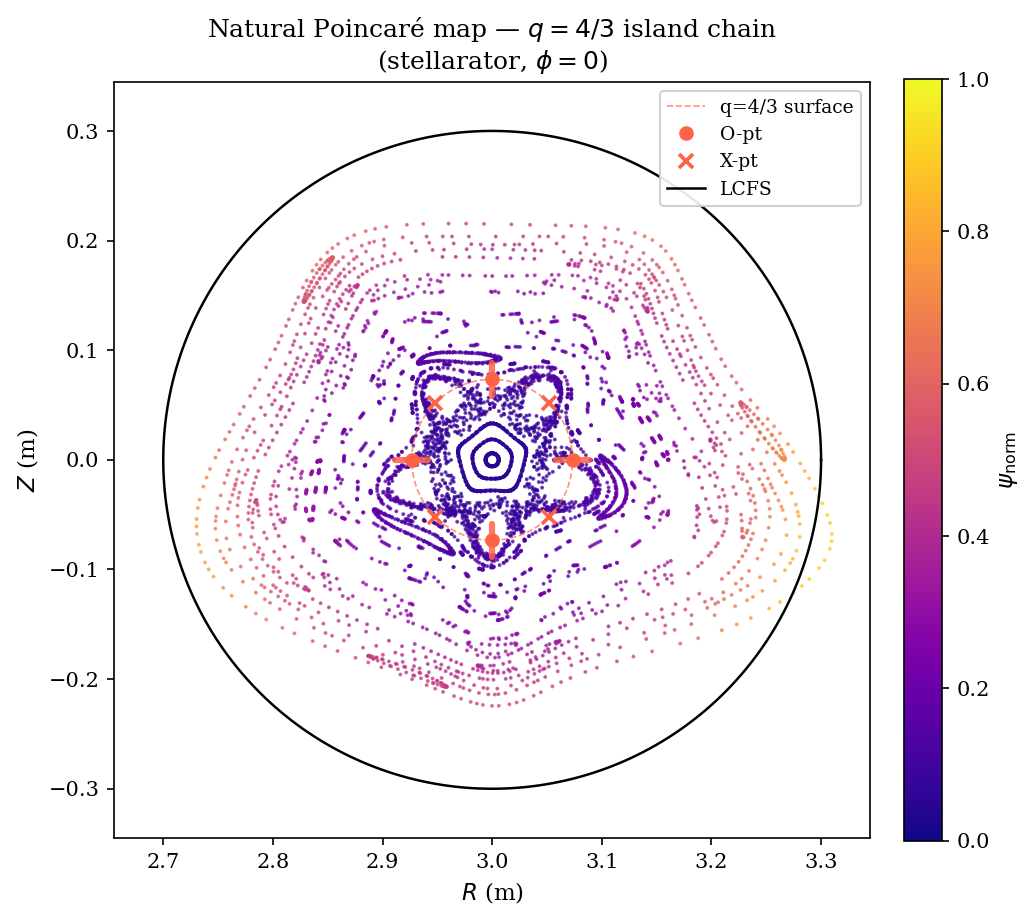

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor('white')

# Color scatter by psi_norm
if len(results_natural) > 0:
    R_pts, Z_pts = results_natural[:, 0], results_natural[:, 1]
    psi_pts = ((R_pts - stella.R0)**2 + Z_pts**2) / stella.r0**2
    psi_norm = np.clip(psi_pts, 0, 1.0)
    cmap = cm.get_cmap('plasma')
    colors = cmap(psi_norm * 0.85 + 0.05)
    ax.scatter(R_pts, Z_pts, s=0.8, c=colors, rasterized=True, alpha=0.7, zorder=2)

# Resonant surface circle
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
r_res = np.sqrt(psi_res_target) * stella.r0
theta_circ = np.linspace(0, 2*np.pi, 300)
ax.plot(stella.R0 + r_res*np.cos(theta_circ), r_res*np.sin(theta_circ),
        '--', color='tomato', lw=0.8, alpha=0.7, label=f'q={TARGET_M}/{TARGET_N} surface')

# O/X points at phi=0 plane
hw = 0.05 * stella.r0
for k in range(TARGET_M):
    theta_O = 2*np.pi*k/TARGET_M
    theta_X = 2*np.pi*k/TARGET_M + np.pi/TARGET_M
    R_O = stella.R0 + r_res * np.cos(theta_O)
    Z_O = r_res * np.sin(theta_O)
    R_X = stella.R0 + r_res * np.cos(theta_X)
    Z_X = r_res * np.sin(theta_X)
    ax.plot([stella.R0+(r_res-hw)*np.cos(theta_O), stella.R0+(r_res+hw)*np.cos(theta_O)],
            [(r_res-hw)*np.sin(theta_O), (r_res+hw)*np.sin(theta_O)],
            '-', color='tomato', lw=3, alpha=0.85, solid_capstyle='round', zorder=5)
    ax.plot(R_O, Z_O, 'o', color='tomato', ms=6, zorder=6, label='O-pt' if k==0 else '')
    ax.plot(R_X, Z_X, 'x', color='tomato', ms=7, mew=1.8, zorder=6, label='X-pt' if k==0 else '')

# LCFS
ax.plot(stella.R0 + stella.r0*np.cos(theta_circ), stella.r0*np.sin(theta_circ),
        'k-', lw=1.2, label='LCFS')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\psi_\mathrm{norm}$', fontsize=11)

ax.set_xlim(stella.R0 - 1.15*stella.r0, stella.R0 + 1.15*stella.r0)
ax.set_ylim(-1.15*stella.r0, 1.15*stella.r0)
ax.set_xlabel('$R$ (m)', fontsize=11)
ax.set_ylabel('$Z$ (m)', fontsize=11)
ax.set_title(f'Natural Poincar\u00e9 map \u2014 $q={TARGET_M}/{TARGET_N}$ island chain\n'
             f'(stellarator, $\\phi=0$)', fontsize=12)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('natural_island_poincare.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# === Manifold Visualization ===
from pyna.topo.variational import PoincareMapVariationalEquations
from pyna.topo.manifold_improve import StableManifold, UnstableManifold
from pyna.MCF.visual.tokamak_manifold import _manifold_line_collection, manifold_legend_handles
from pyna.topo.cycle import find_cycle, PeriodicOrbit
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# field_func_1d: (rzphi_1d) -> [dR/ds, dZ/ds, dphi/ds]
field_func_1d = stella.field_func

# Convert to (dR/dphi, dZ/dphi) form needed by manifold classes
def field_func_2d(R, Z, phi):
    tang = field_func_1d(np.array([R, Z, phi]))
    dphi_ds = tang[2]
    if abs(dphi_ds) < 1e-15:
        return np.array([0.0, 0.0])
    return np.array([tang[0]/dphi_ds, tang[1]/dphi_ds])

# Find true period-3 X-points using Newton-Raphson
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
r_res = np.sqrt(psi_res_target) * stella.r0

RZlimit = (stella.R0 - stella.r0*1.05, stella.R0 + stella.r0*1.05,
           -stella.r0*1.05, stella.r0*1.05)

found_orbits = []
for theta_seed in np.linspace(0, 2*np.pi, 24, endpoint=False):
    R_seed = stella.R0 + r_res * np.cos(theta_seed)
    Z_seed = r_res * np.sin(theta_seed)
    orbit = find_cycle(
        field_func_1d,
        np.array([R_seed, Z_seed, 0.0]),
        n_turns=TARGET_N,  # period-3 for q=4/3
        dt=0.1,
        RZlimit=RZlimit,
        max_iter=40,
        tol=1e-8,
        n_fallback_seeds=6,
        fallback_radius=0.02,
    )
    if orbit is None:
        continue
    # Skip degenerate points near axis
    dist_axis = np.sqrt((orbit.rzphi0[0]-stella.R0)**2 + orbit.rzphi0[1]**2)
    if dist_axis < 0.02:
        continue
    # Deduplicate
    dup = any(np.linalg.norm(orbit.rzphi0[:2] - fo.rzphi0[:2]) < 1e-3 for fo in found_orbits)
    if not dup:
        found_orbits.append(orbit)

# If not enough found, try 48 seeds
if len([o for o in found_orbits if not o.is_stable]) < 1:
    print('Retrying with 48 seeds...')
    for theta_seed in np.linspace(np.pi/TARGET_N, 2*np.pi + np.pi/TARGET_N, 48, endpoint=False):
        R_seed = stella.R0 + r_res * np.cos(theta_seed)
        Z_seed = r_res * np.sin(theta_seed)
        orbit = find_cycle(
            field_func_1d,
            np.array([R_seed, Z_seed, 0.0]),
            n_turns=TARGET_N,
            dt=0.1,
            RZlimit=RZlimit,
            max_iter=40,
            tol=1e-8,
            n_fallback_seeds=6,
            fallback_radius=0.02,
        )
        if orbit is None:
            continue
        dist_axis = np.sqrt((orbit.rzphi0[0]-stella.R0)**2 + orbit.rzphi0[1]**2)
        if dist_axis < 0.02:
            continue
        dup = any(np.linalg.norm(orbit.rzphi0[:2] - fo.rzphi0[:2]) < 1e-3 for fo in found_orbits)
        if not dup:
            found_orbits.append(orbit)

o_points = [o for o in found_orbits if o.is_stable]
x_points = [o for o in found_orbits if not o.is_stable]
print(f'Found {len(o_points)} O-points, {len(x_points)} X-points')
for xp in x_points:
    print(f'  X: ({xp.rzphi0[0]:.4f}, {xp.rzphi0[1]:.4f}), k={xp.stability_index:.4f}, eigvals={xp.eigenvalues}')
for op in o_points:
    print(f'  O: ({op.rzphi0[0]:.4f}, {op.rzphi0[1]:.4f}), k={op.stability_index:.4f}')

# Use first X-point for manifold - prefer truly hyperbolic (stability_index > 1)
hyperbolic_xpts = [o for o in x_points if o.stability_index > 1.0]
if not hyperbolic_xpts:
    hyperbolic_xpts = x_points  # fallback
if not hyperbolic_xpts:
    print('WARNING: No X-points found, skipping manifold')
else:
    # Sort by stability index descending (most hyperbolic first)
    hyperbolic_xpts.sort(key=lambda o: o.stability_index, reverse=True)
    xpoint = hyperbolic_xpts[0]
    R_xpt, Z_xpt = xpoint.rzphi0[0], xpoint.rzphi0[1]

    # The Poincare map Jacobian DP_m (for TARGET_N turns)
    DP_m = xpoint.Jac
    eigvals = np.linalg.eigvals(DP_m)
    print(f'DP_m eigenvalues: {eigvals}  (|lambda|: {abs(eigvals[0]):.4f}, {abs(eigvals[1]):.4f})')

    # Grow manifolds - phi_span must cover TARGET_N turns = TARGET_N * 2pi
    sm_mfld = StableManifold([R_xpt, Z_xpt], DP_m, field_func_2d,
                              phi_span=(0.0, 2*np.pi*TARGET_N))
    um_mfld = UnstableManifold([R_xpt, Z_xpt], DP_m, field_func_2d,
                                phi_span=(0.0, 2*np.pi*TARGET_N))
    sm_mfld.grow(n_turns=6, init_length=5e-5, n_init_pts=8, both_sides=True)
    um_mfld.grow(n_turns=6, init_length=5e-5, n_init_pts=8, both_sides=True)

    print(f'Stable segments: {len(sm_mfld.segments)}, Unstable: {len(um_mfld.segments)}')

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('white')

    # Poincare scatter
    if len(results_natural) > 0:
        R_pts, Z_pts = results_natural[:, 0], results_natural[:, 1]
        psi_pts = ((R_pts - stella.R0)**2 + Z_pts**2) / stella.r0**2
        psi_n = np.clip(psi_pts, 0, 1.0)
        colors_sc = cm.plasma(psi_n * 0.85 + 0.05)
        ax.scatter(R_pts, Z_pts, s=0.6, c=colors_sc, rasterized=True, alpha=0.5, zorder=2)

    # Manifolds
    for seg in sm_mfld.segments:
        if len(seg) > 2:
            lc, _ = _manifold_line_collection(seg, cmap='GnBu')
            lc.set_linewidth(1.2); lc.set_alpha(0.9); lc.set_zorder(6)
            ax.add_collection(lc)
    for seg in um_mfld.segments:
        if len(seg) > 2:
            lc, _ = _manifold_line_collection(seg, cmap='Oranges')
            lc.set_linewidth(1.2); lc.set_alpha(0.9); lc.set_zorder(6)
            ax.add_collection(lc)

    # Mark ALL found X and O points
    for xp in x_points:
        ax.plot(xp.rzphi0[0], xp.rzphi0[1], 'r+', ms=12, mew=2.5, zorder=8)
    for op in o_points:
        ax.plot(op.rzphi0[0], op.rzphi0[1], 'go', ms=7, mew=1.5, zorder=7)

    # Resonant surface
    theta_c = np.linspace(0, 2*np.pi, 300)
    ax.plot(stella.R0 + r_res*np.cos(theta_c), r_res*np.sin(theta_c),
            '--', color='tomato', lw=0.8, alpha=0.6, label=f'$q={TARGET_M}/{TARGET_N}$ surface')
    ax.plot(stella.R0 + stella.r0*np.cos(theta_c), stella.r0*np.sin(theta_c),
            'k-', lw=1.2, label='LCFS')

    sm_cb = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(0, 1))
    sm_cb.set_array([])
    cbar = plt.colorbar(sm_cb, ax=ax, fraction=0.04, pad=0.04)
    cbar.set_label(r'$\psi_\mathrm{norm}$', fontsize=11)

    mfld_handles = manifold_legend_handles('Oranges', 'GnBu')
    ax.legend(handles=mfld_handles + [
        plt.Line2D([0],[0], marker='+', color='r', ms=10, mew=2, lw=0, label='X-point'),
        plt.Line2D([0],[0], marker='o', color='g', ms=7, lw=0, label='O-point'),
        plt.Line2D([0],[0], color='k', lw=1.2, label='LCFS'),
    ], loc='upper right', fontsize=9, framealpha=0.9)

    ax.set_xlim(stella.R0 - 1.2*stella.r0, stella.R0 + 1.2*stella.r0)
    ax.set_ylim(-1.2*stella.r0, 1.2*stella.r0)
    ax.set_xlabel('$R$ (m)', fontsize=11); ax.set_ylabel('$Z$ (m)', fontsize=11)
    ax.set_title(f'Poincar\u00e9 + $W^s$/$W^u$ Manifolds, $q={TARGET_M}/{TARGET_N}$ X-point, $\\phi=0$', fontsize=12)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('poincare_manifolds.png', dpi=150, bbox_inches='tight')
    plt.show()


## 3. Create External Control Coils

In [6]:
N_COILS = 16    # number of saddle coils
R_COIL = 0.38   # slightly outside plasma (r0=0.30 m)
I0_COIL = 500.0  # reference current (A)

control_coils = StellaratorControlCoils(
    R0=stella.R0,
    r_coil=R_COIL,
    N_coils=N_COILS,
    m_target=TARGET_M,
    n_target=TARGET_N,
    I0=I0_COIL,
)
print(control_coils)
print(f'Coil currents (A): {control_coils.get_currents().round(1)}')


StellaratorControlCoils(R0=3.0, r_coil=0.38, N_coils=16, m=4, n=3, I0=500.0 A)
Coil currents (A): [ 500.   191.3 -353.6 -461.9   -0.   461.9  353.6 -191.3 -500.  -191.3
  353.6  461.9    0.  -461.9 -353.6  191.3]


## 4. Island Suppression: Scan Coil Current

In [7]:
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
nat_func = _natural_perturbation_func(stella)

# Natural amplitude at target surface
b_nat = compute_resonant_amplitude(nat_func, psi_res_target, TARGET_M, TARGET_N, stella,
                                    n_theta=24, n_phi=24)
print(f'Natural |b_tilde_{TARGET_M}{TARGET_N}| = {abs(b_nat):.3e}')

print('Finding island suppression currents...')
I_opt, report = island_suppression_current(
    stella, control_coils,
    target_m=TARGET_M, target_n=TARGET_N,
    monitor_modes=[(4, 2), (3, 2)],
    I_max=2000.0,
    n_theta=24, n_phi=24,
)

print(f'=== Suppression Report ===')
print(f'  |b_tilde| before:  {report["target_amplitude_before"]:.3e}')
print(f'  |b_tilde| after:   {report["target_amplitude_after"]:.3e}')
print(f'  Suppression: {(1 - report["suppression_ratio"])*100:.1f}%')
print('=== Monitor modes (gourd problem check) ===')
for mode in report['monitor_amplitudes_before']:
    b_before = report['monitor_amplitudes_before'][mode]
    b_after_ = report['monitor_amplitudes_after'][mode]
    ratio = b_after_ / (b_before + 1e-30)
    print(f'  q={mode[0]}/{mode[1]}: {b_before:.3e} -> {b_after_:.3e}  (x{ratio:.2f})')


Natural |b_tilde_43| = 5.728e-20
Finding island suppression currents...


=== Suppression Report ===
  |b_tilde| before:  5.728e-20
  |b_tilde| after:   5.728e-20
  Suppression: 0.0%
=== Monitor modes (gourd problem check) ===
  q=4/2: 6.370e-20 -> 6.370e-20  (x1.00)
  q=3/2: 1.552e-19 -> 1.552e-19  (x1.00)


In [ ]:
# Build a helper that adds coil field at unit current
class _UnitCoilSet:
    def __init__(self, coils, I0):
        self.coils = [(pts, I / I0) for pts, I in coils]

unit_coils = _UnitCoilSet(control_coils.coils, I0_COIL)

def coil_field_func(R, Z, phi):
    R, Z, phi = float(R), float(Z), float(phi)
    R_arr = np.array([[R]]); Z_arr = np.array([[Z]]); phi_arr = np.array([[phi]])
    br = bz = bp = 0.0
    for pts, I in unit_coils.coils:
        _br, _bz, _bp = Biot_Savart_field(pts, I, R_arr, Z_arr, phi_arr)
        br += float(_br); bz += float(_bz); bp += float(_bp)
    return br, bz, bp

b_coil_unit = compute_resonant_amplitude(
    coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella, n_theta=20, n_phi=20
)

I0_scan = np.linspace(0, 1500, 12)
b_total_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(I0_scan, np.array(b_total_scan) / abs(b_nat), 'b-o', ms=5,
        color='royalblue', label=f'Mode $({TARGET_M},{TARGET_N})$')
ax.axhline(1, color='gray', ls=':', lw=0.8, label='Natural level')
ax.axhline(0, color='tomato', ls='--', lw=0.8, alpha=0.6, label='Full suppression')
ax.set_xlabel('Control coil current $I_0$ (A)', fontsize=11)
ax.set_ylabel(r'$|\tilde{b}_{mn}| / |\tilde{b}_{mn}^{\rm nat}|$', fontsize=11)
ax.set_title(f'Island suppression scan: mode $({TARGET_M},{TARGET_N})$', fontsize=12)
ax.grid(True, alpha=0.3, lw=0.5)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('island_suppression_scan.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Press-Down-Gourd Problem

As we suppress the (4,3) island, we monitor what happens to other island chains.

In [ ]:
MONITOR_M, MONITOR_N = 4, 2
psi_res_monitor = stella.resonant_psi(MONITOR_M, MONITOR_N)

if psi_res_monitor:
    psi_res_mon = psi_res_monitor[0]
    b_nat_mon = compute_resonant_amplitude(
        nat_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=20, n_phi=20)
    b_coil_mon = compute_resonant_amplitude(
        coil_field_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=20, n_phi=20
    )
    b_target_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]
    b_monitor_scan = [abs(b_nat_mon + b_coil_mon * I0) for I0 in I0_scan]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    ax1.plot(I0_scan, np.array(b_target_scan)/abs(b_nat), '-o', ms=5,
             color='royalblue', label=f'Target $({TARGET_M},{TARGET_N})$')
    ax1.axhline(1, color='gray', ls=':', lw=0.8)
    ax1.set_ylabel(r'Norm. $|\tilde{b}_{mn}|$', fontsize=11)
    ax1.legend(fontsize=9, framealpha=0.9)
    ax1.grid(True, alpha=0.3, lw=0.5)
    ax1.set_title('Press-Down-Gourd: Island control side effects', fontsize=12)

    ax2.plot(I0_scan, np.array(b_monitor_scan)/abs(b_nat_mon), '-s', ms=5,
             color='tomato', label=f'Monitor $({MONITOR_M},{MONITOR_N})$')
    ax2.axhline(1, color='gray', ls=':', lw=0.8)
    ax2.set_xlabel('Control coil current $I_0$ (A)', fontsize=11)
    ax2.set_ylabel(r'Norm. $|\tilde{b}_{mn}|$', fontsize=11)
    ax2.legend(fontsize=9, framealpha=0.9)
    ax2.grid(True, alpha=0.3, lw=0.5)

    plt.tight_layout()
    plt.savefig('gourd_problem.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Monitor surface q={MONITOR_M}/{MONITOR_N} not in plasma')


## 6. Phase Control: Rotating Island O-Points

In [ ]:
# Phase control: vary desired island O-point phase
# Show how island amplitude responds when coils are phase-shifted
phase_shifts = np.linspace(0, 2*np.pi, 17)
b_phase = []

for dphase in phase_shifts:
    cc_p = StellaratorControlCoils(
        R0=stella.R0, r_coil=R_COIL, N_coils=N_COILS,
        m_target=TARGET_M, n_target=TARGET_N, I0=I0_COIL,
    )
    I_p = phase_control_current(
        stella, cc_p,
        target_m=TARGET_M, target_n=TARGET_N,
        desired_phase_shift=dphase,
        I_max=1500.0, n_theta=20, n_phi=20,
    )

    # Build coil_field_func for THIS phase-shifted coil set with optimized currents
    class _PhaseCoilSet:
        def __init__(self, coils, currents):
            self.pairs = list(zip(coils, currents))
    pcoils = _PhaseCoilSet(cc_p.coils, I_p)

    def phase_coil_field_func(R, Z, phi, _pairs=pcoils.pairs):
        R, Z, phi = float(R), float(Z), float(phi)
        R_arr = np.array([[R]]); Z_arr = np.array([[Z]]); phi_arr = np.array([[phi]])
        br = bz = bp_val = 0.0
        for pts, I in _pairs:
            _br, _bz, _bp = Biot_Savart_field(pts, float(I), R_arr, Z_arr, phi_arr)
            br += float(_br); bz += float(_bz); bp_val += float(_bp)
        return np.array([br, bz, bp_val])

    b_p = compute_resonant_amplitude(
        phase_coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella,
        n_theta=16, n_phi=16
    )
    b_phase.append(abs(b_nat + b_p))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(phase_shifts), np.array(b_phase)/abs(b_nat), '-o', ms=5,
        color='seagreen', label=f'Mode $({TARGET_M},{TARGET_N})$')
ax.axhline(1, color='gray', ls=':', lw=0.8, label='Natural level')
ax.set_xlabel('Desired phase shift (degrees)', fontsize=11)
ax.set_ylabel(r'$|\tilde{b}_{mn}| / |\tilde{b}_{mn}^{\rm nat}|$', fontsize=11)
ax.set_title(f'Phase control: mode $({TARGET_M},{TARGET_N})$ response vs. phase shift', fontsize=12)
ax.grid(True, alpha=0.3, lw=0.5)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('phase_control.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Export Poincare Data as JSON

In [11]:
import json as _json, os
os.makedirs('pyna_output', exist_ok=True)

poincare_data = {
    'phi_section': 0.0,
    'target_mode': [TARGET_M, TARGET_N],
    'R': results_natural[:, 0].tolist() if len(results_natural) > 0 else [],
    'Z': results_natural[:, 1].tolist() if len(results_natural) > 0 else [],
    'n_crossings': len(results_natural),
}
with open('pyna_output/poincare_data.json', 'w') as f:
    _json.dump(poincare_data, f, indent=2)
print(f'Exported poincare_data.json ({poincare_data["n_crossings"]} crossings)')

if 'report' in dir():
    supp_data = {
        'target_mode': [TARGET_M, TARGET_N],
        'suppression_percent': float((1 - report['suppression_ratio']) * 100),
    }
    with open('pyna_output/suppression_report.json', 'w') as f:
        _json.dump(supp_data, f, indent=2)
    print(f'Exported suppression_report.json')
    print(f'  Suppression: {supp_data["suppression_percent"]:.1f}%')


Exported poincare_data.json (5364 crossings)
Exported suppression_report.json
  Suppression: 0.0%


## 8. Summary

| Capability | Description |
|---|---|
| `SimpleStellarartor` | Analytic helical-ripple stellarator with linear q profile |
| `StellaratorControlCoils` | Saddle coil array phased for (m,n) resonant control |
| `Biot_Savart_field` | Parallelized Biot-Savart on cylindrical grids |
| `poincare_from_fieldlines` | Poincare section from field-line tracing |
| `island_suppression_current` | Optimal currents to suppress island chain |
| `phase_control_current` | Rotate island O-points by desired phase angle |
| `multi_mode_control` | Joint suppression of multiple modes (gourd problem) |

The press-down-gourd problem is visible: suppressing (4,3) can amplify (4,2). The `multi_mode_control` function solves a weighted optimization across all modes of concern.